# Pipeline de préparation des données

Ce notebook lit les radios des 4 classes, applique le pipeline **masque + CLAHE** image par image, exclut les doublons / outliers / images floues identifiés en exploration, puis calcule un jeu de features numériques sauvegardé dans un CSV unique.

Deux modes via la variable `SAVE_IMAGES` :
- `SAVE_IMAGES = False` (défaut) : calcule et écrit uniquement le CSV de features.
- `SAVE_IMAGES = True` : sauvegarde **en plus** chaque image traitée (après masque + CLAHE) dans `output_images_dir/<classe>/<filename>`.

# Génération du CSV de features

Pipeline masque + CLAHE appliqué image par image sur les 4 classes.
Les features numériques sont calculées sur l'image **après** CLAHE et masque.

**Features :** `filename`, `classe`, `pixel_mean`, `pixel_std`, `pixel_median`,
`lum_interieur_masque`, `lum_exterieur_masque`, `surface_masque`, `variance_laplacien`

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import fnmatch

# ── Chemin racine du dataset ──
base_path = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"

normal_path         = os.path.join(base_path, "Normal")
covid_path          = os.path.join(base_path, "COVID")
lungOpacity_path    = os.path.join(base_path, "Lung_Opacity")
viralPneumonia_path = os.path.join(base_path, "Viral Pneumonia")

# ── Chemin de sortie du CSV ──
output_csv = r"C:\Users\Maxime\Documents\Liora_Covid\data\processed\features.csv"

# ── Options de sauvegarde des images traitées ──
SAVE_IMAGES = False  # mettre True pour sauvegarder les images traitées
output_images_dir = r"C:\Users\Maxime\Documents\Liora_Covid\data\processed\images"

In [2]:
# ── Listes de fichiers à exclure (numéros d'images, base 1) ──
# Doublons détectés par MSE (cf. recherche_doublons.ipynb)
doublons_a_supprimer = {
    'Normal': [818],
    'COVID': [140, 591, 158, 160, 229, 21, 376, 403, 224, 232, 234, 237, 1261,
               253, 572, 1299, 761, 599, 52, 729, 1296, 214, 517, 1078, 1111,
               594, 1138, 420, 344, 602, 227, 532, 624, 768, 758, 169, 724,
               1126, 1335, 483, 235, 548, 100, 178, 181, 190, 525, 633, 372,
               766, 1096, 520, 247, 567, 230, 540, 752, 250, 569, 782, 139,
               786, 614, 392, 641, 270, 619, 522, 220, 764, 1167, 744, 492,
               487, 529, 731, 514, 316, 1376, 1373, 792, 1087, 340, 1428, 280,
               419, 848, 1359, 494, 1314, 1443, 497, 1320, 755, 1332, 738,
               1326, 355, 1431, 321, 1123, 1416, 1194, 1188, 428, 463, 1244,
               1437, 846, 1440, 595, 1099, 538, 541, 951, 535, 543, 644, 469,
               684, 486, 1452, 794, 1350, 820, 1356, 873, 1362, 1469, 1264,
               1267, 1276, 1279, 1285, 1288, 609, 1291, 1466, 1353, 695, 1379,
               1341, 1407, 1338, 1434, 1344, 1347, 1389, 1392, 1395, 1425,
               1455, 898, 804, 1458, 1511, 1404, 1526, 1410, 1472, 770, 1323,
               1228, 1574, 1367, 1370, 1422, 1413, 1419, 1505, 1386, 1446,
               1449, 1461, 1520, 1553, 1448, 2085, 2418, 2420, 2421, 2423,
               2432, 2459, 2493, 2667, 2678, 2716, 2717, 2718, 2719, 2773,
               2774, 2805, 2808, 2809, 2810, 2811, 2812, 2813, 2823, 2942,
               2946, 3141, 3142, 3143, 3144, 3208, 3212, 3223, 3299, 3374,
               3375, 3376, 3403, 3427, 3429, 3489, 3516, 3548, 3574, 3591, 3599],
    'Lung_Opacity': [],
    'Viral_Pneumonia': [75, 118, 250, 295, 596, 954, 1053]
}

# Outliers (forte MSE à l'image moyenne de la classe)
outliers_a_supprimer = {
    'Normal': [1485, 1530, 1591, 1834, 2287, 2857, 3068, 3117, 3251, 3336,
               3341, 3344, 3777, 3795, 3872, 3906, 3921, 4355, 4820, 4869,
               5188, 5207, 5224, 5400, 5411, 5422, 5545, 5674, 6128, 6209,
               6811, 7213, 7383, 7501, 7516, 7619, 7634, 7764, 7826, 7859,
               7887, 7932, 8217, 8295, 8694, 8729, 8749, 9147, 9381, 9390,
               9997, 10146, 4213, 4206, 2001],
    'COVID': [324, 500, 585, 1141, 1401, 1413, 1553, 1703, 1730, 1740, 1742,
              2471, 2492, 2493, 2647, 2688, 2750, 3480, 3584, 3615, 3342],
    'Lung_Opacity': [12, 66, 191, 306, 588, 889, 1212, 1657, 2282, 2617, 2731,
                     2959, 2982, 3395, 3560, 3570, 3608, 4351, 4540, 4776, 4791,
                     4871, 4872, 5013],
    'Viral_Pneumonia': []
}

# Images floues (faible variance du Laplacien)
images_floues_a_supprimer = {
    'Normal': [1485, 1530, 1591, 1834, 2287, 2857, 3068, 3117, 3251, 3336,
               3341, 3344, 3777, 3795, 3872, 3906, 3921, 4355, 4820, 4869,
               5188, 5207, 5224, 5400, 5411, 5422, 5545, 5674, 6128, 6209,
               6811, 7213, 7383, 7501, 7516, 7619, 7634, 7764, 7826, 7859,
               7887, 7932, 8217, 8295, 8694, 8729, 8749, 9147, 9381, 9390,
               9997, 10146],
    'COVID': [324, 500, 585, 1141, 1401, 1413, 1553, 1703, 1730, 1740, 1742,
              2471, 2492, 2493, 2647, 2688, 2750, 3480, 3584],
    'Lung_Opacity': [12, 66, 191, 306, 588, 889, 1212, 1657, 2282, 2617, 2731,
                     2959, 2982, 3395, 3560, 3570, 3608, 4351, 4540, 4776, 4791,
                     4871, 4872, 5013],
    'Viral_Pneumonia': []
}

## 1. Comptage des images par classe


In [3]:
nb_files_Normal         = len(fnmatch.filter(os.listdir(os.path.join(normal_path,         "images")), "*.png"))
nb_files_Covid          = len(fnmatch.filter(os.listdir(os.path.join(covid_path,          "images")), "*.png"))
nb_files_LungOpacity    = len(fnmatch.filter(os.listdir(os.path.join(lungOpacity_path,    "images")), "*.png"))
nb_files_ViralPneumonia = len(fnmatch.filter(os.listdir(os.path.join(viralPneumonia_path, "images")), "*.png"))

print('nb_files_Normal         :', nb_files_Normal)
print('nb_files_Covid          :', nb_files_Covid)
print('nb_files_LungOpacity    :', nb_files_LungOpacity)
print('nb_files_ViralPneumonia :', nb_files_ViralPneumonia)
print('Total                   :', nb_files_Normal + nb_files_Covid + nb_files_LungOpacity + nb_files_ViralPneumonia)


nb_files_Normal         : 10192
nb_files_Covid          : 3616
nb_files_LungOpacity    : 6012
nb_files_ViralPneumonia : 1345
Total                   : 21165


## 2. Pipeline masque + CLAHE + extraction des features

Ordre des opérations : chargement brut → détection image noire → CLAHE → application masque → features.


In [4]:
def extract_features_for_class(class_path, class_label, img_prefix, nb_files, a_exclure=None):
    """Extrait les features de chaque image : pipeline masque puis CLAHE.
    Retourne une liste de dict prête à être convertie en DataFrame.

    a_exclure : ensemble/liste de numéros d'images (base 1) à ignorer
                (doublons + outliers + images floues).
    """
    clahe = cv2.createCLAHE(clipLimit=10, tileGridSize=(8, 8))
    a_exclure = set(a_exclure) if a_exclure is not None else set()
    rows = []

    for i in range(nb_files):
        # exclusion des doublons / outliers / images floues (numéros en base 1)
        if (i + 1) in a_exclure:
            continue

        filename  = f"{img_prefix}-{i + 1}.png"
        img_path  = os.path.join(class_path, "images", filename)
        mask_path = os.path.join(class_path, "masks",  filename)

        img_raw  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
        img_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img_raw is None or img_mask is None:
            print(f"  [SKIP] {filename} — fichier manquant")
            continue

        # redimensionnement masque 256x256 → 299x299 (INTER_NEAREST pour conserver le masque binaire)
        img_mask_resized = cv2.resize(
            img_mask,
            (img_raw.shape[1], img_raw.shape[0]),
            0, 0,
            cv2.INTER_NEAREST
        )
        mask_bin = img_mask_resized > 127  # seuil 127 : binarisation du masque

        # surface du masque (proportion pixels pulmonaires sur l'image resizée)
        surface_masque = float(mask_bin.sum()) / float(mask_bin.size)

        # CLAHE appliqué sur l'image brute, puis application du masque
        img_eq    = cv2.equalizeHist(img_raw)
        img_clahe = clahe.apply(img_eq)
        img_masked = cv2.bitwise_and(img_clahe, img_mask_resized)

        # toutes les features numériques sur l'image après CLAHE + masque
        pixel_mean   = float(img_masked.mean())
        pixel_std    = float(img_masked.std())
        pixel_median = float(np.median(img_masked))

        lum_interieur_masque = float(img_masked[mask_bin].mean())  if mask_bin.any()   else float('nan')
        lum_exterieur_masque = float(img_masked[~mask_bin].mean()) if (~mask_bin).any() else float('nan')

        variance_laplacien = float(cv2.Laplacian(img_masked, cv2.CV_64F).var())

        # sauvegarde optionnelle de l'image traitée (après masque + CLAHE)
        if SAVE_IMAGES:
            class_out_dir = os.path.join(output_images_dir, class_label)
            os.makedirs(class_out_dir, exist_ok=True)
            cv2.imwrite(os.path.join(class_out_dir, filename), img_masked)

        rows.append({
            'filename'             : filename,
            'classe'               : class_label,
            'pixel_mean'           : round(pixel_mean, 4),
            'pixel_std'            : round(pixel_std, 4),
            'pixel_median'         : pixel_median,
            'lum_interieur_masque' : round(lum_interieur_masque, 4),
            'lum_exterieur_masque' : round(lum_exterieur_masque, 4),
            'surface_masque'       : round(surface_masque, 6),
            'variance_laplacien'   : round(variance_laplacien, 4),
        })

        if (i + 1) % 500 == 0:
            print(f"  {i + 1} / {nb_files} images traitées")

    print(f"  {len(rows)} images traitées — classe {class_label} terminée.")
    return rows

## 3. Extraction pour les 4 classes


In [5]:
# Configuration des 4 classes
# (class_path, class_label_csv, img_prefix, nb_files)
# img_prefix : préfixe du nom de fichier tel que stocké dans le dataset
classes_config = [
    (covid_path,          'COVID',           'COVID',          nb_files_Covid),
    (normal_path,         'Normal',          'Normal',         nb_files_Normal),
    (lungOpacity_path,    'Lung_Opacity',    'Lung_Opacity',   nb_files_LungOpacity),
    (viralPneumonia_path, 'Viral_Pneumonia', 'Viral Pneumonia', nb_files_ViralPneumonia),
]

all_rows = []
for class_path, class_label, img_prefix, nb_files in classes_config:
    # union des doublons + outliers + images floues pour la classe
    a_exclure = (
        set(doublons_a_supprimer.get(class_label, []))
        | set(outliers_a_supprimer.get(class_label, []))
        | set(images_floues_a_supprimer.get(class_label, []))
    )
    print(f"\n=== {class_label} ({nb_files} images, {len(a_exclure)} exclues) ===")
    rows = extract_features_for_class(class_path, class_label, img_prefix, nb_files, a_exclure=a_exclure)
    all_rows.extend(rows)

print(f"\nTotal lignes extraites : {len(all_rows)}")


=== COVID (3616 images, 241 exclues) ===
  1000 / 3616 images traitées
  1500 / 3616 images traitées
  2000 / 3616 images traitées
  2500 / 3616 images traitées
  3000 / 3616 images traitées
  3500 / 3616 images traitées
  3375 images traitées — classe COVID terminée.

=== Normal (10192 images, 56 exclues) ===
  500 / 10192 images traitées
  1000 / 10192 images traitées
  1500 / 10192 images traitées
  2000 / 10192 images traitées
  2500 / 10192 images traitées
  3000 / 10192 images traitées
  3500 / 10192 images traitées
  4000 / 10192 images traitées
  4500 / 10192 images traitées
  5000 / 10192 images traitées
  5500 / 10192 images traitées
  6000 / 10192 images traitées
  6500 / 10192 images traitées
  7000 / 10192 images traitées
  7500 / 10192 images traitées
  8000 / 10192 images traitées
  8500 / 10192 images traitées
  9000 / 10192 images traitées
  9500 / 10192 images traitées
  10000 / 10192 images traitées
  10136 images traitées — classe Normal terminée.

=== Lung_Opacity

## 4. Construction du DataFrame et sauvegarde


In [6]:
# Création du dossier de sortie si nécessaire
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

df_features = pd.DataFrame(all_rows)

# Ordre des colonnes
df_features = df_features[[
    'filename', 'classe',
    'pixel_mean', 'pixel_std', 'pixel_median',
    'lum_interieur_masque', 'lum_exterieur_masque',
    'surface_masque', 'variance_laplacien',
]]

df_features.to_csv(output_csv, index=False)
print(f"CSV sauvegardé : {output_csv}")
print(f"Shape : {df_features.shape}")

CSV sauvegardé : C:\Users\Maxime\Documents\Liora_Covid\data\processed\features.csv
Shape : (20837, 9)


## 5. Aperçu et statistiques descriptives


In [7]:
print("── 5 premières lignes ──")
display(df_features.head())


── 5 premières lignes ──


,filename,classe,pixel_mean,pixel_std,pixel_median,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-1.png,COVID,24.1884,48.6138,0.0,102.3016,0.2693,0.234427,640.4867
1,COVID-2.png,COVID,23.5659,47.1873,0.0,94.1861,0.4038,0.246977,733.1919
2,COVID-3.png,COVID,23.8735,44.4828,0.0,89.2368,0.3305,0.264807,652.1350
3,COVID-4.png,COVID,31.3344,57.6973,0.0,102.5699,0.6327,0.301182,736.5547
4,COVID-5.png,COVID,24.4690,49.7481,0.0,97.7249,0.3962,0.247335,698.0943


In [8]:
print("── Répartition par classe ──")
display(df_features['classe'].value_counts().to_frame('n_images'))


── Répartition par classe ──


,n_images
classe,
Normal,10136
Lung_Opacity,5988
COVID,3375
Viral_Pneumonia,1338


In [9]:
print("── Statistiques descriptives (features numériques) ──")
display(df_features.describe())


── Statistiques descriptives (features numériques) ──


,pixel_mean,pixel_std,pixel_median,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,20837.000000,20837.000000,20837.000000,20837.000000,20837.000000,20837.000000,20837.000000
mean,24.367494,49.011779,0.009358,100.557986,0.384402,0.238633,774.273764
std,6.829253,6.263250,0.515230,7.737069,0.101103,0.061394,159.512593
min,2.737700,18.031900,0.000000,75.352000,0.051600,0.029004,179.614600
25%,19.604900,44.964000,0.000000,95.735300,0.314500,0.195859,666.258800
50%,23.807300,49.053400,0.000000,99.335700,0.379200,0.235120,762.001600
75%,28.496100,53.048700,0.000000,103.659500,0.446500,0.277133,867.597800
max,67.635300,78.002700,49.000000,172.764600,1.109400,0.580072,2755.949400


## 6. Visualisation du pipeline sur une image exemple


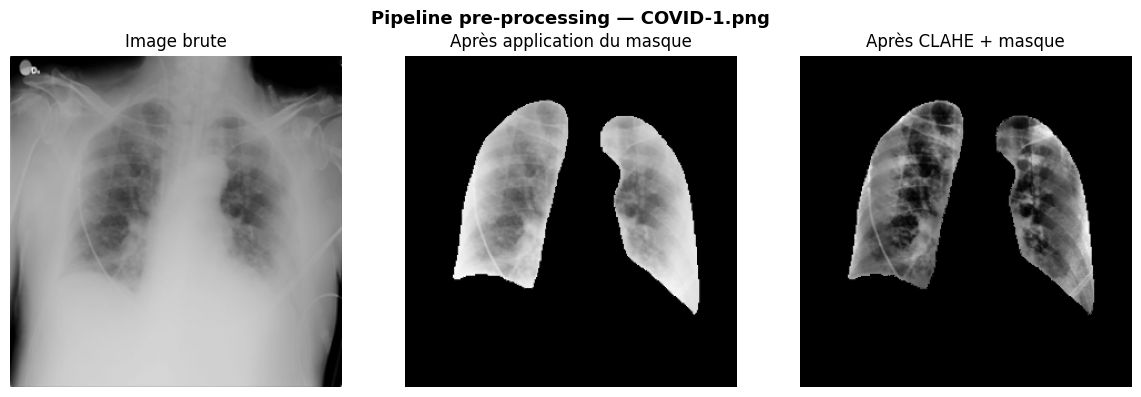

Figure sauvegardée : C:\Users\Maxime\Documents\Liora_Covid\reports\figures\exemple_pipeline.png


In [10]:
import matplotlib.pyplot as plt

# ── Chargement COVID-1.png ──
img_path  = os.path.join(covid_path, "images", "COVID-1.png")
mask_path = os.path.join(covid_path, "masks",  "COVID-1.png")

img_raw  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
img_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Redimensionnement masque 256x256 → 299x299 (INTER_NEAREST pour conserver le masque binaire)
img_mask_resized = cv2.resize(img_mask, (img_raw.shape[1], img_raw.shape[0]), 0, 0, cv2.INTER_NEAREST)

# Étape intermédiaire : masque appliqué sur image brute (pour montrer la segmentation)
img_avec_masque = cv2.bitwise_and(img_raw, img_mask_resized)

# Étape finale : CLAHE puis masque (pipeline complet)
clahe_viz  = cv2.createCLAHE(clipLimit=10, tileGridSize=(8, 8))
img_finale = cv2.bitwise_and(clahe_viz.apply(cv2.equalizeHist(img_raw)), img_mask_resized)

# ── Figure ──
output_fig = r"C:\Users\Maxime\Documents\Liora_Covid\reports\figures\exemple_pipeline.png"
os.makedirs(os.path.dirname(output_fig), exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_raw, cmap="gray")
axes[0].set_title("Image brute")
axes[0].axis("off")

axes[1].imshow(img_avec_masque, cmap="gray")
axes[1].set_title("Après application du masque")
axes[1].axis("off")

axes[2].imshow(img_finale, cmap="gray")
axes[2].set_title("Après CLAHE + masque")
axes[2].axis("off")

fig.suptitle("Pipeline pre-processing — COVID-1.png", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(output_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {output_fig}")
